In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from warnings import filterwarnings
filterwarnings("ignore")

c:\Users\mnour\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df=pd.read_csv("C:\\Users\\mnour\\Desktop\\ObesityDataSet_raw_and_data_sinthetic.csv")
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


About this file

Gender – Male or Female.
Age – The person’s age in years.
Height – Height in meters.
Weight – Weight in kilograms.
family_history_with_overweight – Whether the person has a family history of being overweight (yes/no).
FAVC – If the person frequently consumes high-calorie foods (yes/no).
FCVC – Frequency of vegetable consumption (scale from 1 to 3).
NCP – Number of main meals per day.
CAEC – Frequency of consuming food between meals (Never, Sometimes, Frequently, Always).
SMOKE – Whether the person smokes (yes/no).
CH2O – Daily water intake (scale from 1 to 3).
SCC – If the person monitors their calorie intake (yes/no).
FAF – Physical activity frequency (scale from 0 to 3).
TUE – Time spent using technology (scale from 0 to 3).
CALC – Frequency of alcohol consumption (Never, Sometimes, Frequently, Always).
MTRANS – Main mode of transportation (Automobile, Bike, Motorbike, Public Transportation, Walking).
NObeyesdad – Obesity level (Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, Obesity Type I, Obesity Type II, Obesity Type III).

In [3]:
df.shape

(2111, 17)

In [4]:
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight',
       'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE',
       'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   str    
 1   Age                             2111 non-null   int64  
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   str    
 5   FAVC                            2111 non-null   str    
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   str    
 9   SMOKE                           2111 non-null   str    
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   str    
 12  FAF                             2111 non-null

In [6]:
pd.DataFrame(df.isnull().sum(), columns=['Null Count']).sort_values(by='Null Count', ascending=False)

,Null Count
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,2087.0,24.356493,6.379977,14.00,20.000,23.000,26.000,61.00
Height,2087.0,1.702616,0.093251,1.45,1.630,1.700,1.770,1.98
Weight,2087.0,86.858706,26.190838,39.00,66.000,83.100,108.015,173.00
FCVC,2087.0,2.421409,0.534807,1.00,2.000,2.400,3.000,3.00
NCP,2087.0,2.701203,0.764655,1.00,2.700,3.000,3.000,4.00
CH2O,2087.0,2.004792,0.608281,1.00,1.590,2.000,2.465,3.00
FAF,2087.0,1.012827,0.853496,0.00,0.125,1.000,1.680,3.00
TUE,2087.0,0.663031,0.608152,0.00,0.000,0.631,1.000,2.00


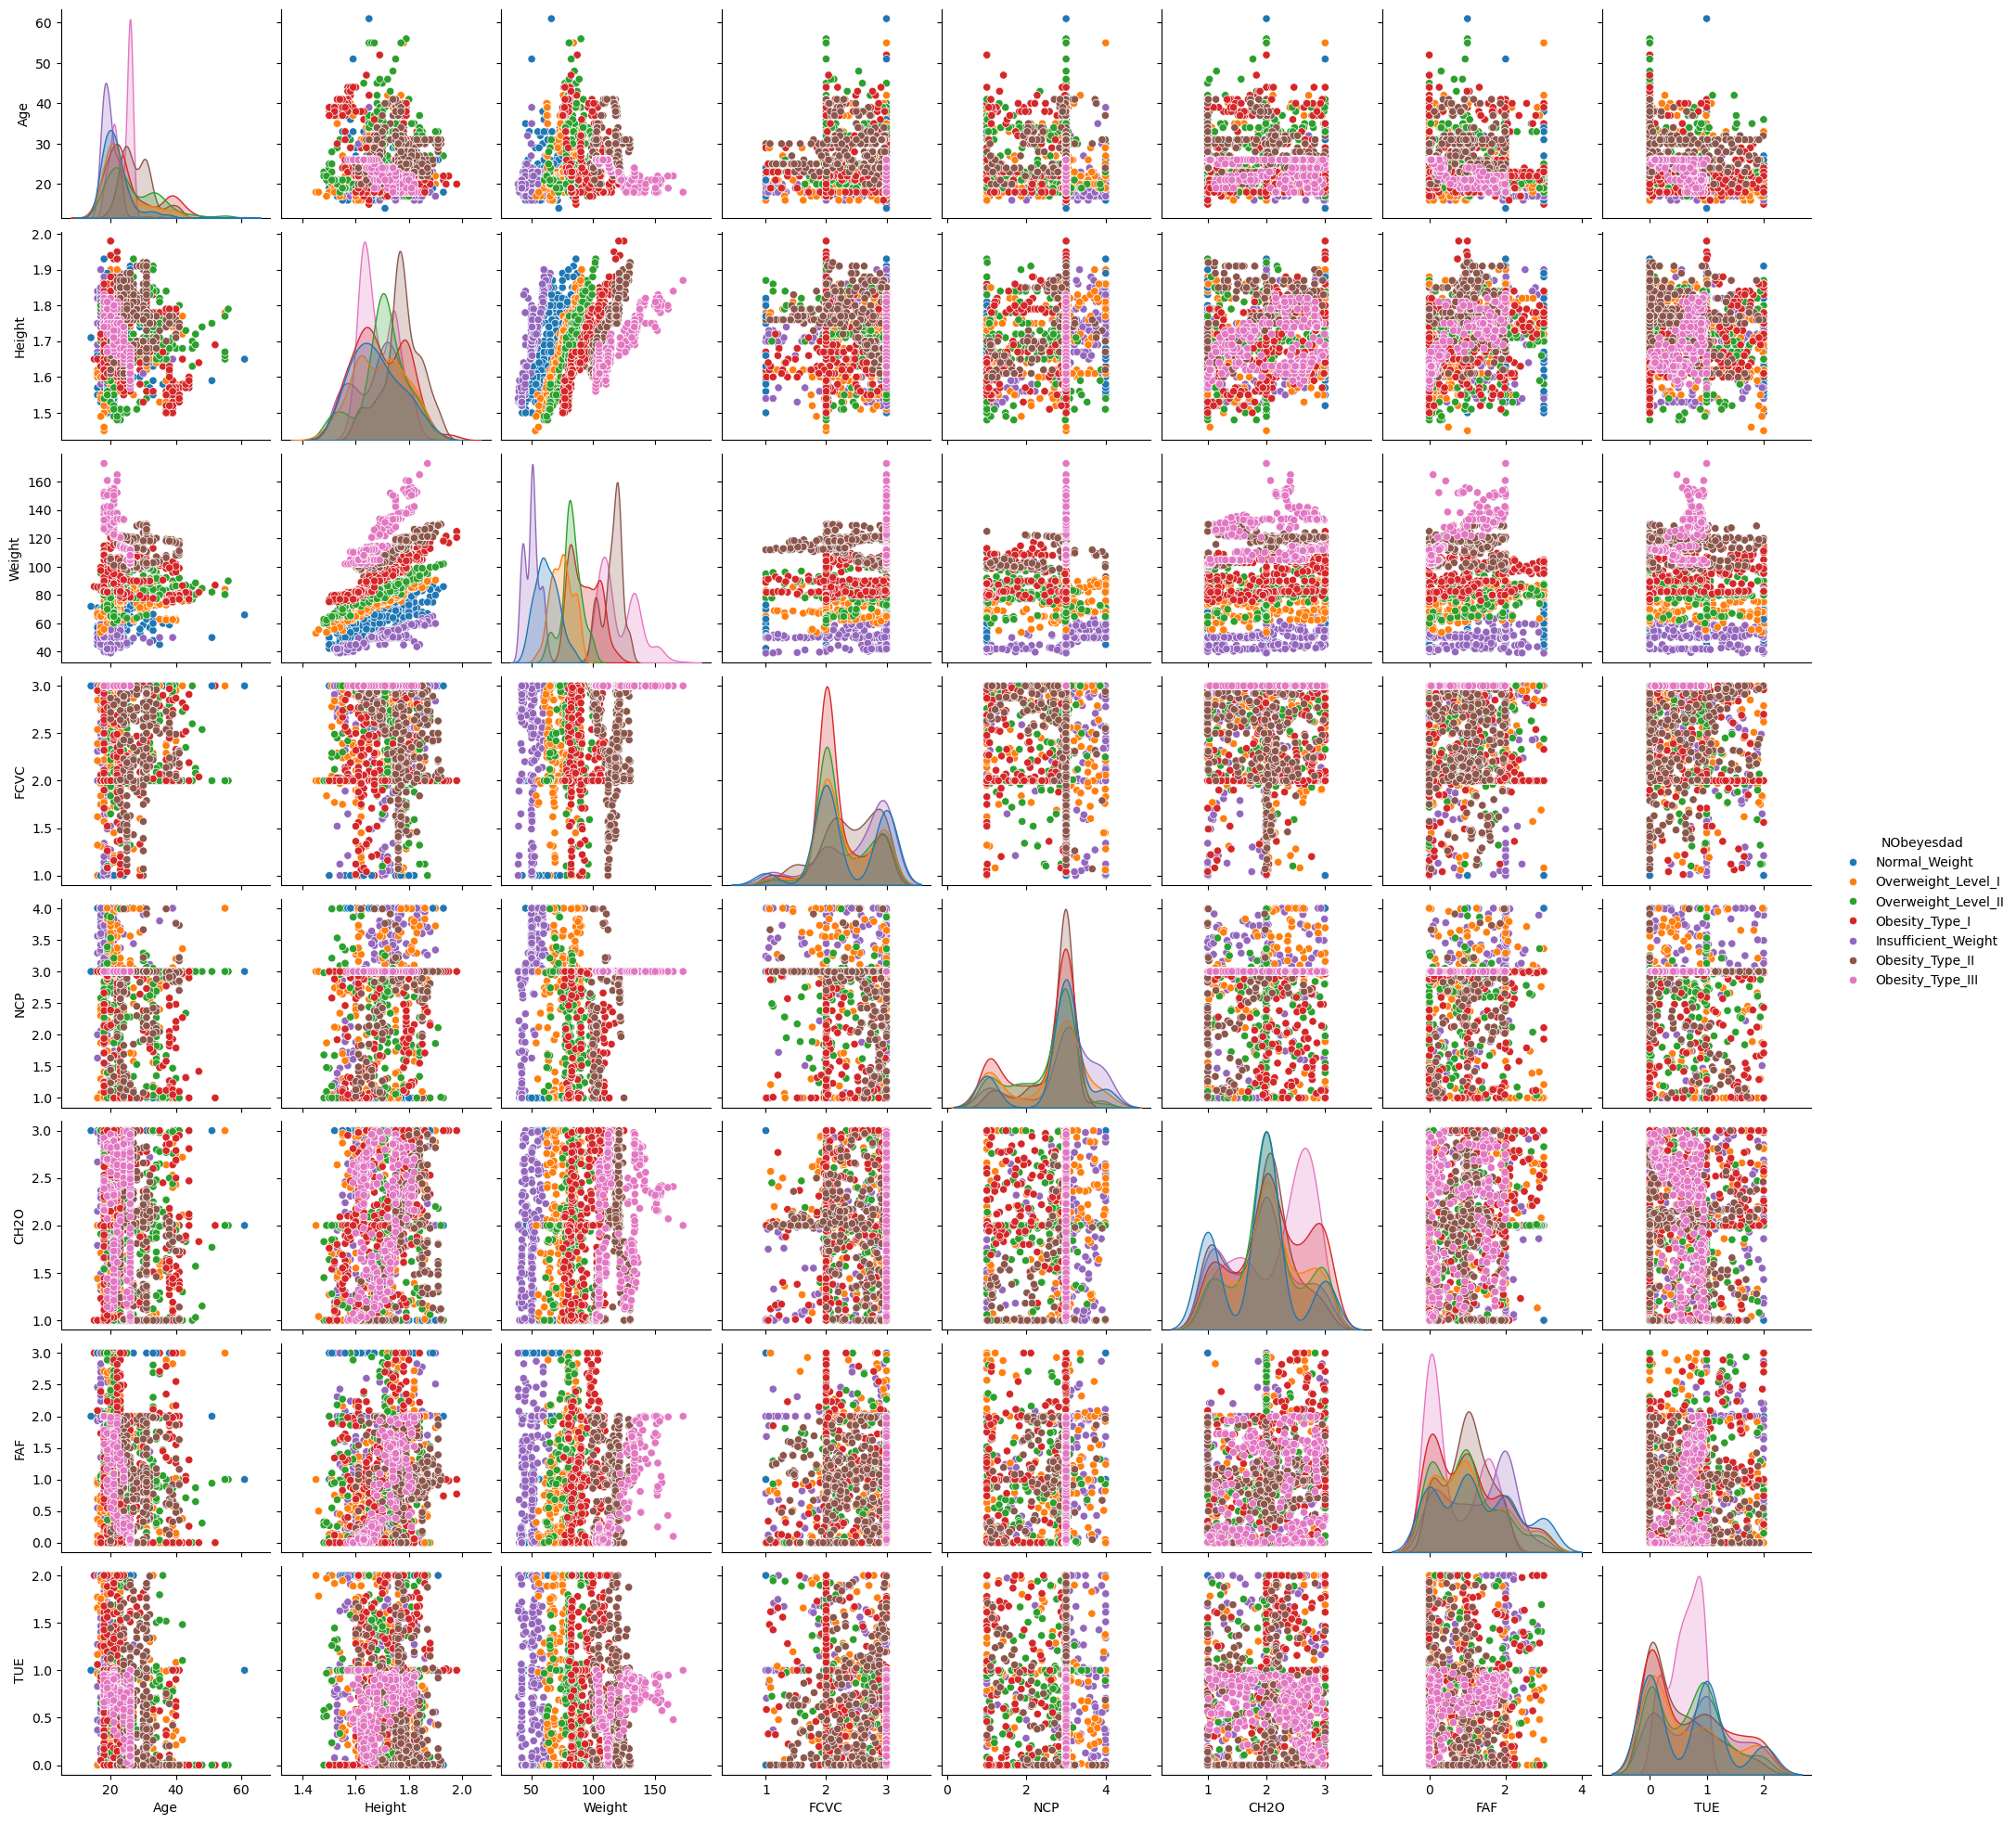

In [10]:
sns.pairplot(df, hue='NObeyesdad')
plt.show()

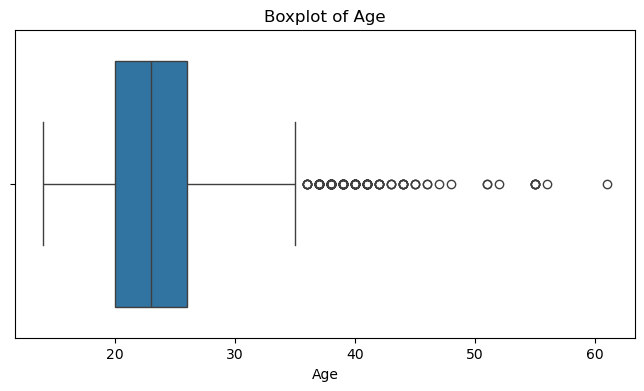

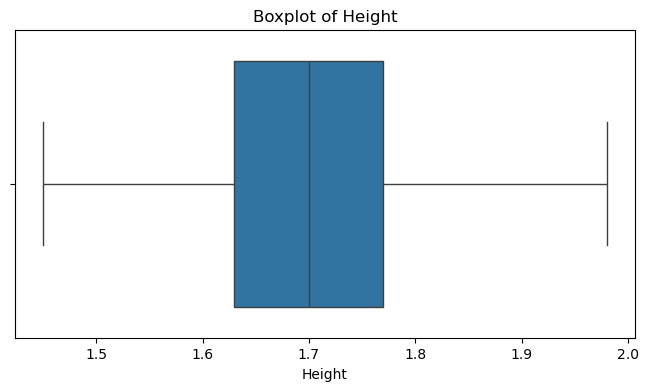

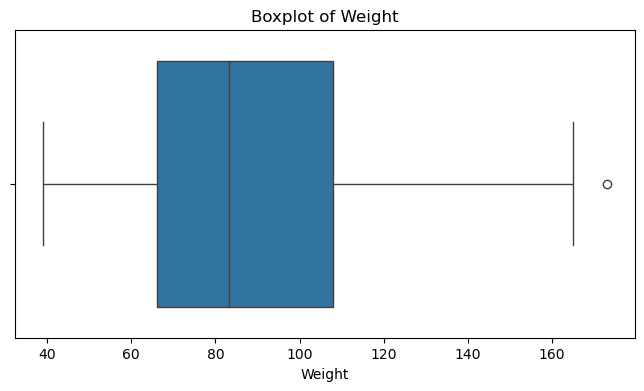

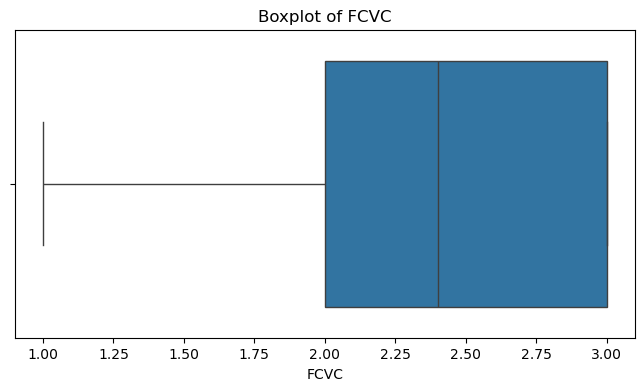

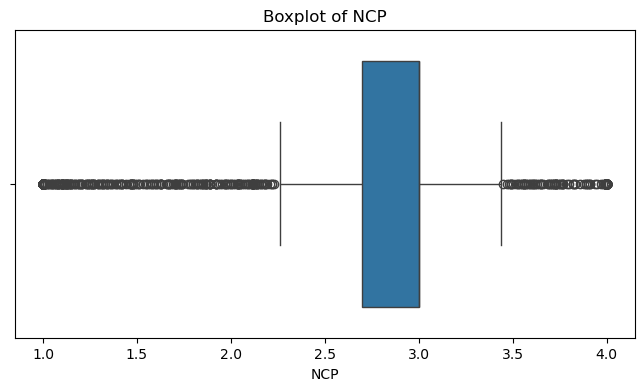

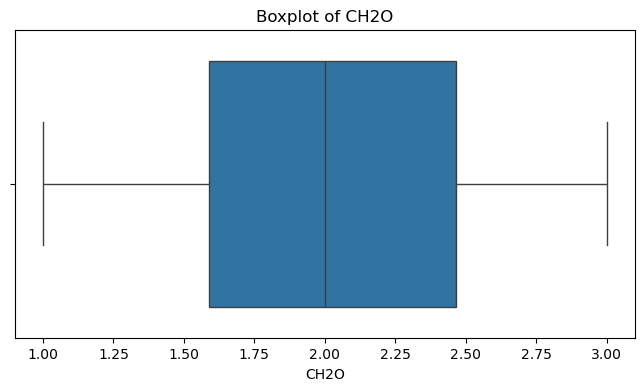

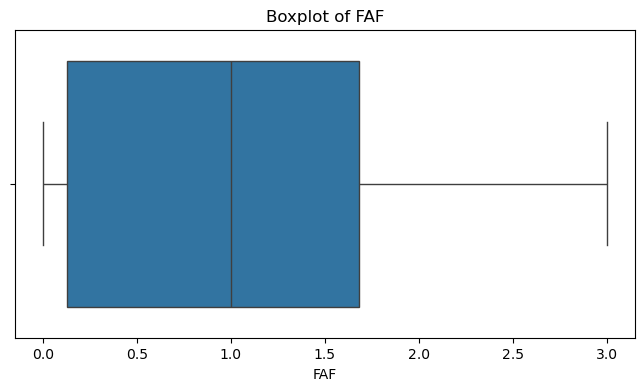

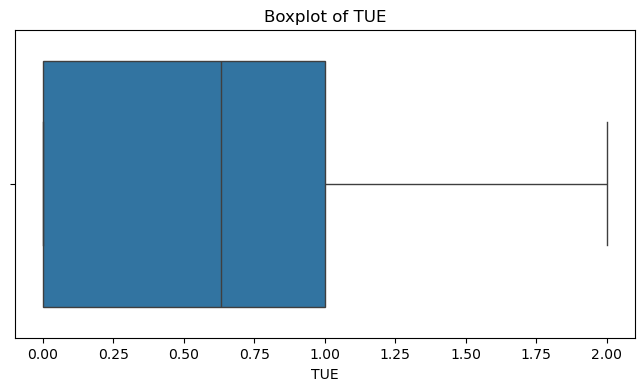

In [11]:
for column in df.select_dtypes(include=np.number).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot of {column}')
    plt.show()



In [12]:
#number of outliers in each numerical column using IQR method
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
Q1 = df[numerical_cols].quantile(0.25)
Q3 = df[numerical_cols].quantile(0.75)
IQR = Q3 - Q1
outliers = ((df[numerical_cols] < (Q1 - 1.5 * IQR)) | (df[numerical_cols] > (Q3 + 1.5 * IQR))).sum()
pd.DataFrame(outliers.to_frame().rename(columns={0:'Outliers'})).head(15) 



,Outliers
Age,160
Height,0
Weight,1
FCVC,0
NCP,578
CH2O,0
FAF,0
TUE,0


In [13]:
df.shape

(2087, 17)

<Axes: xlabel='Age', ylabel='Count'>

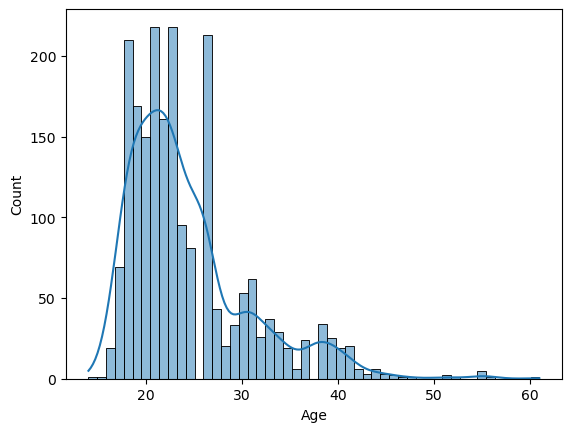

In [14]:
sns.histplot(df["Age"], kde=True)

<Axes: xlabel='NCP', ylabel='Count'>

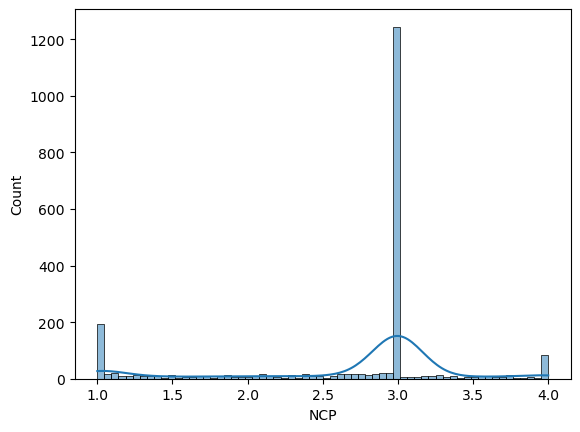

In [15]:
sns.histplot(df['NCP'], kde=True)

In [16]:
def handle_outliers_iqr(df, method="cap", target_col=None):

    df = df.copy()
    cleaned_cols = []

    num_cols = df.select_dtypes(include='number').columns

    for col in num_cols:

 
        if col == target_col:
            continue

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        if method == "cap":
            df[col] = df[col].clip(lower, upper)

  
        elif method == "drop":
            df = df[(df[col] >= lower) & (df[col] <= upper)]

        cleaned_cols.append(col)


    return df
df = handle_outliers_iqr(df, method="drop")
df.describe().T



,count,mean,std,min,25%,50%,75%,max
Age,1384.0,23.227601,4.229267,14.00,20.0000,23.000,26.0000,35.00
Height,1384.0,1.714082,0.087178,1.45,1.6500,1.710,1.7700,1.95
Weight,1384.0,92.061720,27.393373,39.00,70.0000,90.585,112.7950,173.00
FCVC,1384.0,2.455759,0.549588,1.00,2.0000,2.560,3.0000,3.00
NCP,1384.0,2.970405,0.139674,2.28,3.0000,3.000,3.0000,3.43
CH2O,1384.0,2.049191,0.604884,1.00,1.6775,2.000,2.5425,3.00
FAF,1384.0,1.025723,0.848512,0.00,0.1400,1.000,1.6200,3.00
TUE,1384.0,0.699562,0.584792,0.00,0.1250,0.691,1.0000,2.00


In [17]:
df.shape

(1384, 17)

In [18]:

numeric_cols = df.select_dtypes(include=[np.number]).columns
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Skewness of numeric features:")
print(skewness)


Skewness of numeric features:
Age       0.638406
TUE       0.561776
FAF       0.500235
Weight    0.038337
Height   -0.044827
CH2O     -0.210227
FCVC     -0.564518
NCP      -2.336072
dtype: float64


In [19]:
# Apply log transformation for features with |skewness| > 1
for col in numeric_cols:
    if abs(skewness[col]) > 1:
        df[col] = np.log1p(df[col]) 

In [20]:
#Encode categorical features with label encoding

label_encoder = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])
for i in df.columns:
    if i != 'NObeyesdad':
        df[i] = MinMaxScaler().fit_transform(df[[i]])
df.head()

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0.0,0.333333,0.34,0.186567,1.0,0.0,0.5,0.660279,0.666667,0.0,0.5,0.0,0.000000,0.5,1.0,0.75,1
1,0.0,0.333333,0.14,0.126866,1.0,0.0,1.0,0.660279,0.666667,1.0,1.0,1.0,1.000000,0.0,0.5,0.75,1
2,1.0,0.428571,0.70,0.283582,1.0,0.0,0.5,0.660279,0.666667,0.0,0.5,0.0,0.666667,0.5,0.0,0.75,1
3,1.0,0.619048,0.70,0.358209,0.0,0.0,1.0,0.660279,0.666667,0.0,0.5,0.0,0.666667,0.0,0.0,1.00,5
5,1.0,0.714286,0.34,0.104478,0.0,1.0,0.5,0.660279,0.666667,0.0,0.5,0.0,0.000000,0.0,0.5,0.00,1


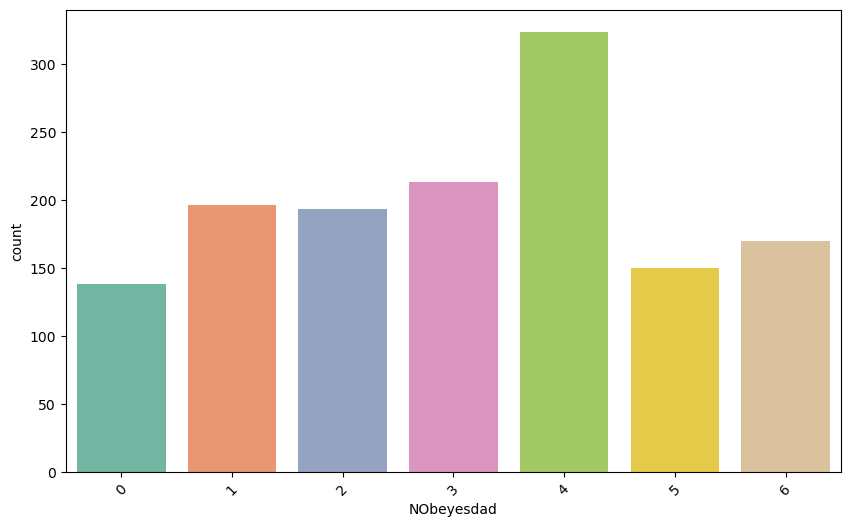

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(x='NObeyesdad', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.show()

In [22]:
#split the data into features and target variable
X = df.drop(columns=['NObeyesdad'])  # Drop the target column from features
y = df["NObeyesdad"]  # Select the target column as the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [23]:
#apply SMOTE to balance the classes in the training set
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)   
print("Original training set class distribution:")
print(y_train.value_counts())
print("\nBalanced training set class distribution:")
print(y_train_balanced.value_counts())


Original training set class distribution:
NObeyesdad
4    253
3    174
1    160
2    149
5    133
6    129
0    109
Name: count, dtype: int64

Balanced training set class distribution:
NObeyesdad
4    253
2    253
0    253
5    253
6    253
3    253
1    253
Name: count, dtype: int64


  File "c:\Users\mnour\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
                        pass_fds, cwd, env,
                        ^^^^^^^^^^^^^^^^^^^
    ...<5 lines>...
                        gid, gids, uid, umask,
                        ^^^^^^^^^^^^^^^^^^^^^^
                        start_new_session, process_group)
                        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\mnour\anaconda3\Lib\subprocess.

In [24]:

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)





In [25]:
model.fit(X_train_balanced, y_train_balanced)
y_pred = model.predict(X_test)
from sklearn.metrics import classification_report, confusion_matrix
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.69        29
           1       0.56      0.53      0.54        36
           2       0.77      0.52      0.62        44
           3       0.75      1.00      0.86        39
           4       0.99      1.00      0.99        71
           5       0.36      0.88      0.51        17
           6       0.71      0.37      0.48        41

    accuracy                           0.73       277
   macro avg       0.69      0.71      0.67       277
weighted avg       0.76      0.73      0.72       277



In [26]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[19  9  0  0  0  1  0]
 [ 6 19  1  0  0  7  3]
 [ 0  1 23  8  1  8  3]
 [ 0  0  0 39  0  0  0]
 [ 0  0  0  0 71  0  0]
 [ 0  1  1  0  0 15  0]
 [ 1  4  5  5  0 11 15]]


In [27]:
#applay decision tree
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train_balanced, y_train_balanced)
y_pred_dt = dt_model.predict(X_test)
print("Decision Tree Classification Report:")
print(classification_report(y_test, y_pred_dt))


Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.79      0.82        29
           1       0.82      0.78      0.80        36
           2       0.94      1.00      0.97        44
           3       1.00      0.97      0.99        39
           4       0.99      1.00      0.99        71
           5       0.71      1.00      0.83        17
           6       1.00      0.85      0.92        41

    accuracy                           0.92       277
   macro avg       0.90      0.91      0.90       277
weighted avg       0.93      0.92      0.92       277



In [28]:

scaler = MinMaxScaler()
scaler.fit(X_train_balanced)



new_sample = pd.DataFrame([{
    'Gender': 'Male',
    'Age': 23,
    'Height': 1.80,
    'Weight': 77.0,
    'family_history_with_overweight': 'yes',
    'FAVC': 'no',
    'FCVC': 2.0,
    'NCP': 3.0,
    'CAEC': 'Sometimes',
    'SMOKE': 'no',
    'CH2O': 2.0,
    'SCC': 'no',
    'FAF': 2.0,
    'TUE': 1.0,
    'CALC': 'Frequently',
    'MTRANS': 'Public_Transportation'
}])

new_sample_encoded = pd.get_dummies(new_sample)


new_sample_encoded = new_sample_encoded.reindex(
    columns=X_train.columns,
    fill_value=0
)


new_sample_scaled = scaler.transform(new_sample_encoded)


prediction = model.predict(new_sample_scaled)

print("Predicted obesity category:", prediction[0])

Predicted obesity category: 3
